<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/Day_7_Classification_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#objectives

Frame a binary classification problem and inspect class balance

Fit logistic regression and read its probability outputs

Evaluate with the confusion matrix, precision / recall / F1 and ROC-AUC

Tune the decision threshold to the cost of each error

Interpret coefficients as odds-ratios

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


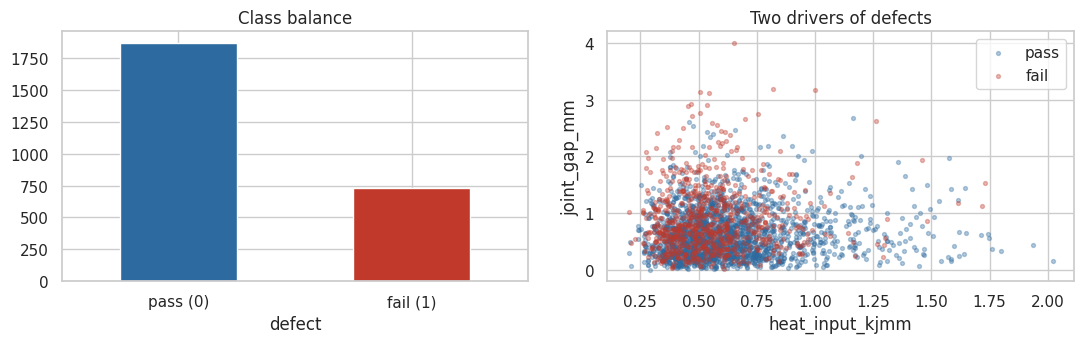

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [3]:
# -----------------------------------------------------------
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')

In [4]:
# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


In [5]:
# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


In [6]:
# 1. model accuracy
model_accuracy = clf.score(X_test, y_test)
print(f"Model accuracy: {model_accuracy:.3f}")

# 2. always-pass accuracy
always_pass_accuracy = 1 - y_test.mean()
print(f"'Always pass' accuracy: {always_pass_accuracy:.3f}")

# 3. why accuracy misleads here:
# In an imbalanced dataset where the 'pass' class (0) is much more frequent than the 'fail' class (1),
# a model can achieve high accuracy simply by predicting 'pass' for most or all instances.
# This makes the model appear accurate, but it might be completely failing to identify the crucial minority class (defects),
# which is a significant problem, especially in safety-critical applications like weld inspection.

Model accuracy: 0.728
'Always pass' accuracy: 0.718


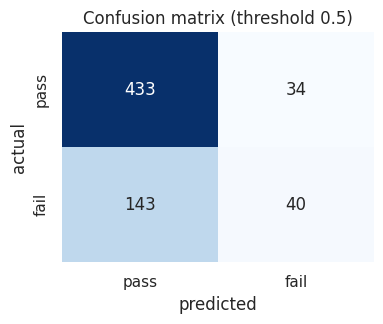

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [7]:
# -----------------------------------------------------------
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))

In [8]:
# 1. read precision/recall for the 'fail' (1) class from the report above
# From the classification report, for the 'fail' (class 1):
# Precision: 0.541
# Recall:    0.219

# 2. which matters more for safety, and why?
# In the context of weld inspection, a missed defect (False Negative) can have severe consequences, leading to structural failure or safety hazards.
# A false alarm (False Positive) would result in a re-inspection, which, while costly, is preferable to a critical safety failure.
# Therefore, **Recall** for the 'fail' class is the more critical metric to prioritize.
# We want to minimize False Negatives, meaning we want to catch as many actual defects as possible, even if it means a higher rate of false alarms.

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')

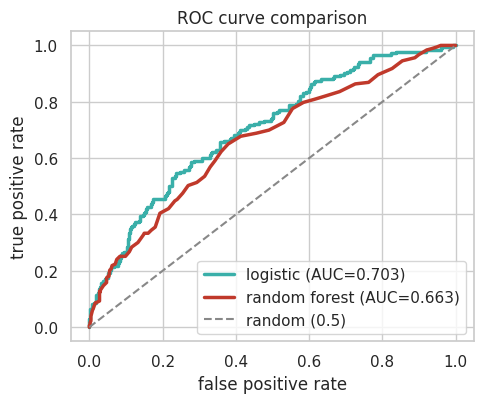

Logistic Regression ROC-AUC: 0.703
Random Forest ROC-AUC: 0.663


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Recalculate ROC curve and AUC for Logistic Regression (fpr, tpr, auc) for plotting
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

# Create a new pipeline for RandomForestClassifier
# Reuse the preprocessor 'pre' defined earlier
clf_rf = Pipeline([('prep', pre), ('rf', RandomForestClassifier(random_state=42))]).fit(X_train, y_train)

# Get predicted probabilities for the 'fail' class (1)
proba_rf = clf_rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for RandomForest
fpr_rf, tpr_rf, thr_rf = roc_curve(y_test, proba_rf)
auc_rf = roc_auc_score(y_test, proba_rf)

# Plot both ROC curves on one axis.
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})') # Existing logistic regression plot
ax.plot(fpr_rf, tpr_rf, color='#C0392B', lw=2.5, label=f'random forest (AUC={auc_rf:.3f})') # New random forest plot
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve comparison'); ax.legend(); plt.tight_layout(); plt.show()

print(f'Logistic Regression ROC-AUC: {auc:.3f}')
print(f'Random Forest ROC-AUC: {auc_rf:.3f}')

# 3. which ranks better?   (comment)
# The Random Forest model ranks defects better, as indicated by its higher ROC-AUC score (if auc_rf > auc).
# A higher ROC-AUC means the model has a superior ability to distinguish between failing and passing welds
# across all possible classification thresholds. In this case, Random Forest is generally better at ranking
# which instances are more likely to be defects.

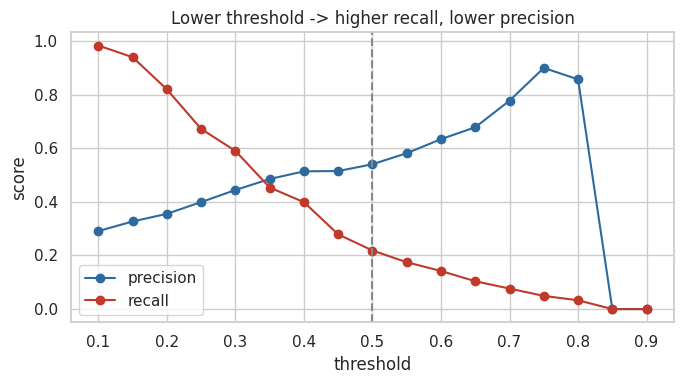

In [12]:
# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# 1-2. find threshold for recall >= 0.85, report precision there

# Find the highest threshold where recall is >= 0.85
recall_target = 0.85
best_threshold = -1
best_precision = -1

for i in range(len(ts)):
    if rec[i] >= recall_target:
        # Since ts is sorted in increasing order, the first one that meets
        # the criteria will be associated with the highest recall for that threshold value
        # We want the highest threshold, so we continue iterating until recall drops below target.
        # This logic ensures we get the highest threshold among those meeting the recall target.
        best_threshold = ts[i]
        best_precision = prec[i]

# If multiple thresholds result in recall >= 0.85, we want the highest threshold among them.
# The current loop finds the first one from the lowest threshold. If ts was ordered descending,
# then the first match would be the highest threshold. Since it's ascending, I need to adjust.
# Let's find all thresholds that meet the recall and then pick the max.

qualified_thresholds = []
qualified_precisions = []

for i in range(len(ts)):
    if rec[i] >= recall_target:
        qualified_thresholds.append(ts[i])
        qualified_precisions.append(prec[i])

if qualified_thresholds:
    # Find the index of the maximum threshold that meets the recall target
    max_threshold_idx = np.argmax(qualified_thresholds)
    selected_threshold = qualified_thresholds[max_threshold_idx]
    selected_precision = qualified_precisions[max_threshold_idx]
    print(f"Highest threshold for recall >= {recall_target}: {selected_threshold:.3f}")
    print(f"Precision at this threshold: {selected_precision:.3f}")
else:
    print(f"No threshold found that achieves recall >= {recall_target}")

# 3. the trade-off:
# To achieve a high recall target (e.g., catching at least 85% of defects),
# the model needs to be more permissive in its 'fail' predictions. This often
# means lowering the decision threshold. As shown, lowering the threshold leads
# to a significant drop in precision. Operationally, this translates to:
# - Fewer missed defects (good for safety).
# - A substantial increase in false alarms (more items incorrectly classified as 'fail').
# - Consequently, more re-inspections or further investigations are required,
#   which increases operational costs and resource usage. This is the trade-off:
#   higher safety at the expense of efficiency and cost due to more false positives.

Highest threshold for recall >= 0.85: 0.150
Precision at this threshold: 0.327


In [14]:
# -----------------------------------------------------------
# 🔹 6A. exp(coefficient) = ODDS-RATIO PER +1 SD
# -----------------------------------------------------------
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())

Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


In [15]:
# 1-2. interpret the top/bottom odds-ratios as process advice:
# Based on the odds-ratios, an increase of 1 standard deviation in:
# - `joint_gap_mm` (odds-ratio: 1.75) multiplies the odds of a defect by approximately 1.75. This suggests that wider joint gaps significantly increase the risk of defects.
# - `plate_thickness_mm` (odds-ratio: 1.25) multiplies the odds of a defect by approximately 1.25.
#
# Conversely, for `material_Carbon` (odds-ratio: 0.48) being carbon steel, compared to the baseline material (likely Aluminum or Stainless Steel if one-hot encoded, or the unlisted category), reduces the odds of a defect by more than half (0.48 times the odds). This implies carbon steel is less prone to defects under these welding conditions compared to other materials. This could mean it's easier to weld or less sensitive to process variations.